In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
np.random.seed(42)

data = pd.DataFrame({
    "hours_studied": np.random.randint(1, 10, 50),
    "attendance": np.random.randint(50, 100, 50),

})

data.head()


,hours_studied,attendance
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [5]:
x = data[["hours_studied","attendance"]]

model = KMeans(n_clusters=3, random_state=42, n_init=10)
data["Cluster"] = model.fit_predict(x)

data.head()

,hours_studied,attendance,Cluster
0,7,53,1
1,4,51,1
2,8,55,1
3,5,91,0
4,7,53,1


In [7]:
score = silhouette_score(x, data["Cluster"])
print("silhouette_score: ", score)

silhouette_score:  0.5276411515754762


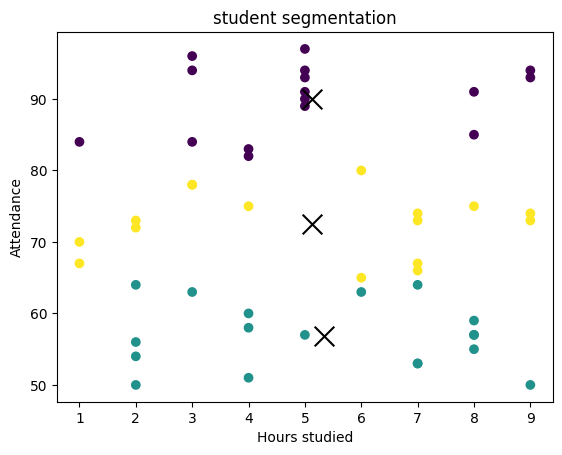

In [9]:
plt.scatter(data["hours_studied"], data["attendance"], c=data["Cluster"])

centers= model.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c="black", marker="x", s=200)

plt.xlabel("Hours studied")
plt.ylabel("Attendance")
plt.title("student segmentation")
plt.show()

In [12]:
new_student = [[6,80]]

predicted_cluster = model.predict(new_student)

print("New student belongs to cluster: ", predicted_cluster[0])

New student belongs to cluster:  2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [14]:
data.groupby("Cluster").mean()

,hours_studied,attendance
Cluster,,
0,5.125000,90.000000
1,5.333333,56.888889
2,5.125000,72.500000
